[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Quantlets/Ch_00/SFM_ch0_seminar/SFM_ch0_seminar.ipynb)

# Statistics of Financial Markets — Seminar 0: Prices, Returns, Volatility and Drawdown

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before the Chapter 0 lecture: the definitions are in the primer below.
- **[Solved]** exercises show the full code and output: use them as models. **[Proposed]** exercises have an empty code cell: solve them yourself; the solutions are discussed in class. Nothing is handed in.

> Quantlet `SFM_ch0_seminar`: student version of the Seminar 0 notebook. Solved exercises (A1, A2, A3, B1, B2) are shown with code and output; the proposed exercises (A4, B3, B4, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_0'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

In [ ]:
# the palette names as attributes of the style namespace `st` (st.MainBlue, st.Teal, ...)
for _c in ('MainBlue', 'IDAred', 'Forest', 'Amber', 'Purple', 'Orange', 'Teal', 'Crimson', 'DarkText'):
    setattr(st, _c, globals()[_c])

## Setup

### Primer

- Simple return $R_t = P_t/P_{t-1} - 1$; log return $r_t = \ln(P_t/P_{t-1})$.
- Simple returns compound, log returns add: $\ln(P_T/P_0) = \sum_t r_t$.
- Annualised mean $= q\,\bar r$, annualised volatility $= \sqrt{q}\, s$, with $q$ observations per year (about 252 for exchanges, 365 for Bitcoin).
- Drawdown $DD_t = P_t / \max_{s\le t} P_s - 1$; the maximum drawdown is its most negative value.

### Seminar functions

In [ ]:
START = '2015-01-02'


def paper_returns(prices):
    """Simple and log returns (%) of a short price path, and the two-period totals."""
    p = np.asarray(prices, dtype=float)
    R = 100 * (p[1:] / p[:-1] - 1)
    r = 100 * np.log(p[1:] / p[:-1])
    return {'R': R, 'r': r, 'sum_R': R.sum(), 'sum_r': r.sum(),
            'total_R': 100 * (p[-1] / p[0] - 1), 'total_r': 100 * np.log(p[-1] / p[0])}


def paper_drawdown(prices):
    """Running peak, drawdown DD_t = P_t / max_{s<=t} P_s - 1 (%) and maximum drawdown of a short path."""
    p = pd.Series(prices, dtype=float)
    peak = p.cummax()
    dd = 100 * (p / peak - 1)
    return {'peak': peak.values, 'dd': dd.values, 'mdd': dd.min(), 'mdd_day': int(dd.idxmin())}


def annualise(mean_daily, sd_daily, days):
    """Annualised mean (times days) and volatility (times the square root of days), in %."""
    return mean_daily * days, sd_daily * np.sqrt(days)


def describe(name, start=START):
    """Prices -> simple and log returns -> annualised mean and volatility, cumulative return, drawdown."""
    p = load_close(name, start)
    R = p.pct_change().dropna()
    r = np.log(p).diff().dropna()
    q = periods_per_year(r)
    dd = p / p.cummax() - 1
    trough = dd.idxmin()
    peak = p.loc[:trough].idxmax()
    return {'prices': p, 'R': R, 'r': r, 'dd': dd, 'n_prices': len(p), 'n': len(r),
            'first_date': str(p.index[0].date()), 'last_date': str(p.index[-1].date()),
            'P0': p.iloc[0], 'P1': p.iloc[1], 'P2': p.iloc[2], 'PT': p.iloc[-1],
            'R1': 100 * R.iloc[0], 'r1': 100 * r.iloc[0], 'R2': 100 * R.iloc[1], 'r2': 100 * r.iloc[1],
            'q': q, 'mean_d': 100 * r.mean(), 'sd_d': 100 * r.std(),
            'ann_mean': 100 * r.mean() * q, 'ann_vol': 100 * r.std() * np.sqrt(q),
            'ann_vol_252': 100 * r.std() * np.sqrt(252), 'ann_vol_365': 100 * r.std() * np.sqrt(365),
            'cum': 100 * (p.iloc[-1] / p.iloc[0] - 1), 'cum_from_r': 100 * (np.exp(r.sum()) - 1),
            'mdd': 100 * dd.min(), 'mdd_date': str(trough.date()), 'mdd_peak': str(peak.date()),
            'max_R': 100 * R.max(), 'max_R_date': str(R.idxmax().date()),
            'min_R': 100 * R.min(), 'min_R_date': str(R.idxmin().date())}


def fig_growth(d, name, label, colour, save=True):
    """Value of 100 invested on the first day (cumulative return), linear scale."""
    g = 100 * d['prices'] / d['prices'].iloc[0]
    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(g.index, g, color=colour, lw=1.2, label=f'{label}: value of 100 invested')
    ax.axhline(100, color=st.MainBlue, lw=0.6, ls='--', label='Starting value 100')
    ax.set_ylabel('Value')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig(name)


def fig_drawdown(d, name, label, colour, save=True):
    """Drawdown (%) with the maximum drawdown marked."""
    dd = 100 * d['dd']
    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.fill_between(dd.index, dd, 0, color=colour, alpha=0.35, label=f'{label}: drawdown')
    ax.plot(dd.index, dd, color=colour, lw=0.8)
    t = dd.idxmin()
    ax.scatter([t], [dd[t]], color=st.IDAred, zorder=3, label=f'Maximum drawdown {dd[t]:.1f}% ({t:%d %b %Y})')
    ax.set_ylabel('Drawdown, %')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig(name)


def eurron_check(start='2015-01-01'):
    """The EODHD EUR/RON quote furthest from the BNR reference rate of the same day, and its two daily moves."""
    m = load_close('eurron_eodhd', start)
    b = load_close('eurron', start)
    gap = 100 * (m / b.reindex(m.index) - 1)
    t = gap.abs().idxmax()
    i = m.index.get_loc(t)
    r = 100 * np.log(m).diff()
    rb = 100 * np.log(b).diff().dropna()
    return {'m': m, 'b': b, 'date': str(t.date()), 'quote': m.iloc[i], 'prev': m.iloc[i - 1],
            'next': m.iloc[i + 1], 'prev_date': str(m.index[i - 1].date()), 'next_date': str(m.index[i + 1].date()),
            'move_in': r.iloc[i], 'move_out': r.iloc[i + 1], 'bnr': b[t], 'gap': gap[t],
            'n_big': int((r.abs() > 2).sum()), 'n_gap': int((gap.abs() > 2).sum()),
            'bnr_max_move': rb.abs().max(), 'n_m': len(m), 'n_b': len(b)}


def fig_eurron(c, save=True):
    """EODHD quotes and the BNR rate in the month around the suspicious quote."""
    t = pd.Timestamp(c['date'])
    a, z = t - pd.Timedelta(days=20), t + pd.Timedelta(days=20)
    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(c['m'].loc[a:z].index, c['m'].loc[a:z], color=st.Orange, lw=1.2, marker='o', ms=3,
            label='EUR/RON series from EODHD')
    ax.plot(c['b'].loc[a:z].index, c['b'].loc[a:z], color=st.MainBlue, lw=1.4, marker='s', ms=3,
            label='EUR/RON, BNR reference rate')
    ax.annotate(f'{t:%d %b %Y}: {c["quote"]:.4f}', (t, c['quote']), xytext=(10, 0), textcoords='offset points',
                fontsize=10.5, color='black')
    ax.set_ylabel('RON per EUR')
    st.legend_outside_bottom(ax, ncol=2, y=-0.14)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch0_sem_b2_eurron')

### Setup check

- Expected: 2944 prices from 2015-01-02 to 2026-09-18; first close 2058.20.

In [ ]:
p = load_close('sp500', start='2015-01-02')
print(len(p), p.index[0].date(), p.index[-1].date())
print(p.head(3).round(2))

## A1 [Solved]: Simple and log returns

**Question:** can two daily returns simply be added to get the two-day return? **Inputs:** $P_0 = 100$, $P_1 = 110$, $P_2 = 99$.

1. Compute the simple returns $R_1, R_2$ and the log returns $r_1, r_2$.
2. Add the two simple returns, and then add the two log returns.
3. Compute the two-day returns and compare them with the sums.

**Report:** the table and one sentence on which returns add up.

In [8]:
# Solution
a1 = paper_returns([100, 110, 99])
print('simple returns, %:', a1['R'].round(2), ' log returns, %:', a1['r'].round(2))
print('sums, %:', round(a1['sum_R'], 2), round(a1['sum_r'], 3))
print('two-day returns, %:', round(a1['total_R'], 2), round(a1['total_r'], 3))

simple returns, %: [ 10. -10.]  log returns, %: [  9.53 -10.54]
sums, %: 0.0 -1.005
two-day returns, %: -1.0 -1.005


**Interpretation:** the sum of the simple returns is 0% for a path that lost 1%; log returns add up, simple returns compound.

## A2 [Solved]: Annualisation

**Inputs:** a stock index with daily mean log return 0.05% and daily volatility 1.2%; Bitcoin with daily volatility 3%.

1. Annualise the mean and the volatility of the index with $q = 252$.
2. Annualise the volatility of Bitcoin with $q = 365$, and then with $q = 252$.
3. Explain which $q$ is right for Bitcoin.

In [9]:
# Solution
print('index, mean and volatility per year (%):', [round(x, 2) for x in annualise(0.05, 1.2, 252)])
print('Bitcoin, volatility with 365 and 252 days (%):', round(3 * np.sqrt(365), 2), round(3 * np.sqrt(252), 2))

index, mean and volatility per year (%): [12.6, np.float64(19.05)]
Bitcoin, volatility with 365 and 252 days (%): 57.31 47.62


**Interpretation:** $q$ is the number of observations per year of the series; Bitcoin trades every day, so $q = 365$.

## A3 [Solved]: Drawdown on paper

**Inputs:** prices on days 0–5: 100, 120, 90, 110, 130, 104.

1. Compute the running peak $M_t$.
2. Compute the drawdown $DD_t$.
3. Find the maximum drawdown.

In [10]:
# Solution
a3 = paper_drawdown([100, 120, 90, 110, 130, 104])
print(pd.DataFrame({'P': [100, 120, 90, 110, 130, 104], 'peak': a3['peak'], 'DD %': a3['dd'].round(1)}))
print('maximum drawdown, %:', a3['mdd'], 'on day', a3['mdd_day'])

     P   peak  DD %
0  100  100.0   0.0
1  120  120.0   0.0
2   90  120.0 -25.0
3  110  120.0  -8.3
4  130  130.0   0.0
5  104  130.0 -20.0
maximum drawdown, %: -25.0 on day 2


## B1 [Solved]: The S&P 500, 2015–2026

**Question:** how much did the S&P 500 return, and how risky was it?

1. Compute the daily simple and log returns; check the first two step by step.
2. Compute $q$, the annualised mean log return and the annualised volatility.
3. Compute the cumulative return $P_T/P_0 - 1$ and check it against $\exp(\sum_t r_t) - 1$.
4. Plot the value of 100 invested and the drawdown; find the maximum drawdown with its dates.

**Report:** $q$, annual mean and volatility, cumulative return, maximum drawdown with dates, and one sentence.

In [11]:
# Solution
d = describe('sp500')
for k in ('P0', 'P1', 'P2', 'R1', 'r1', 'R2', 'r2', 'n', 'q', 'ann_mean', 'ann_vol', 'cum', 'cum_from_r',
          'mdd', 'mdd_peak', 'mdd_date'):
    print(f'{k:12s}', round(d[k], 3) if isinstance(d[k], float) else d[k])

P0           2058.2
P1           2020.58
P2           2002.61
R1           -1.828
r1           -1.845
R2           -0.889
r2           -0.893
n            2943
q            251.505
ann_mean     11.22
ann_vol      17.69
cum          271.708
cum_from_r   271.708
mdd          -33.925
mdd_peak     2020-02-19
mdd_date     2020-03-23


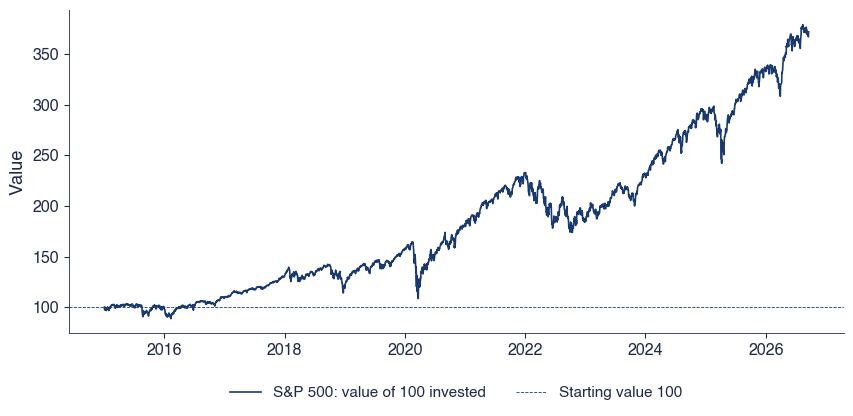

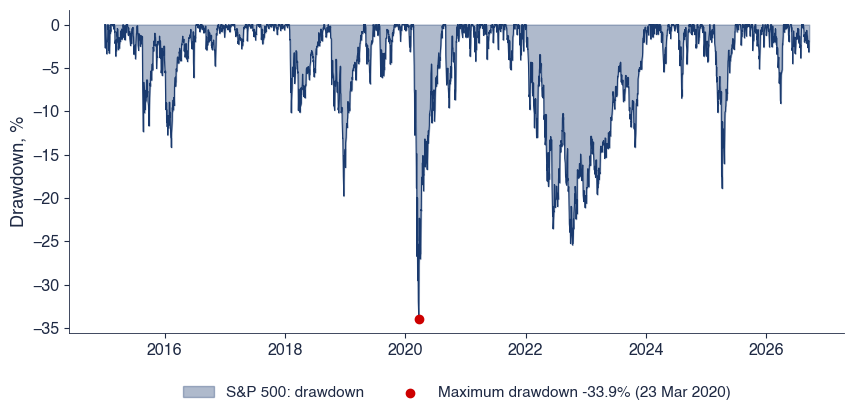

In [12]:
fig_growth(d, 'ch0_sem_b1_growth', 'S&P 500', st.MainBlue, save=False)
plt.show()
fig_drawdown(d, 'ch0_sem_b1_drawdown', 'S&P 500', st.MainBlue, save=False)
plt.show()

**Interpretation:** a good average year hides a fall of about a third in one month (March 2020); report the volatility and the drawdown next to the mean.

## B2 [Solved]: One suspicious quote

**Question:** is the largest EUR/RON move in the EODHD series a real price? **Inputs:** the EUR/RON series from EODHD (`eurron_eodhd`) and the BNR reference rate (`eurron`).

1. Compute the gap between the EODHD quote and the BNR rate of the same day.
2. Find the day with the largest absolute gap; print the quotes of the day before and after.
3. Compute the log returns into and out of that day.
4. Plot both series in the month around that day.

date           2025-08-13
prev           5.0636
quote          5.9065
next           5.0629
bnr            5.0633
gap            16.6532
move_in        15.3976
move_out       -15.4114
bnr_max_move   1.4169


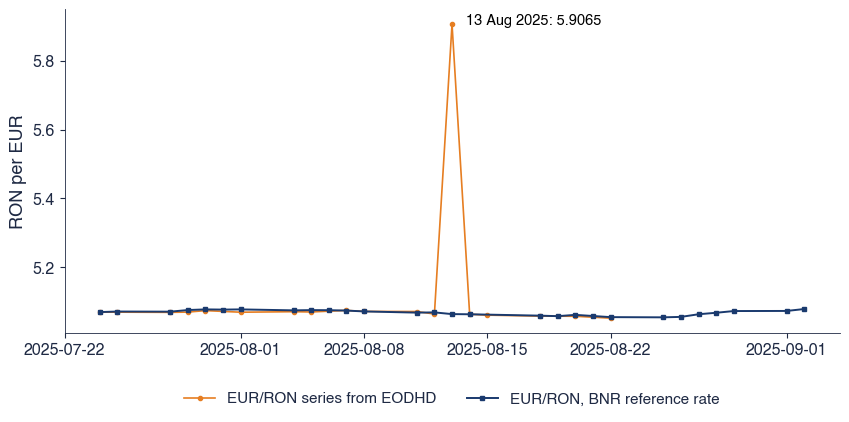

In [13]:
# Solution
c = eurron_check()
for k in ('date', 'prev', 'quote', 'next', 'bnr', 'gap', 'move_in', 'move_out', 'bnr_max_move'):
    print(f'{k:14s}', round(c[k], 4) if isinstance(c[k], float) else c[k])
fig_eurron(c, save=False)
plt.show()

**Interpretation:** a jump that fully reverses the next day and is absent from the official rate is a bad tick; the course uses the BNR rate for EUR/RON.

## A4 [Proposed]: New numbers

**Model:** A1, A2 and A3 [Solved]. **Inputs:** a share at 50, 55, 44; a fund at 200, 180, 220, 165, 198, 230 on days 0–5; daily mean 0.03% and daily volatility 1.5%.

1. Compute the simple and log returns of the share, their sums and the two-day returns.
2. Compute the drawdown of the fund for each day and its maximum drawdown.
3. Annualise the daily mean and volatility with $q = 252$.

In [ ]:
# Your code here


## B3 [Proposed]: The BET-TR, 2015–2026

**Model:** B1 [Solved]; reuse its code with `describe('bettr')`.

1. Compute $q$, the annualised mean log return and the annualised volatility.
2. Compute the cumulative return and the maximum drawdown with its dates.
3. Compare each number with the S&P 500 result of B1.

**Report:** a two-column table and one sentence: why is the comparison not fully fair?

In [ ]:
# Your code here


## B4 [Proposed]: Bitcoin, 365 or 252 days?

**Model:** A2 and B1 [Solved].

1. Compute $q$ from the data.
2. Compute the annualised volatility with $q = 365$ and with $q = 252$.
3. Compute the cumulative return and the maximum drawdown with its dates.

In [ ]:
# Your code here


## C2 [Proposed]: Critique an AI answer

**Prompt** sent to an AI assistant: *From the course data, compute the annualised volatility and the cumulative return of the S&P 500 and of Bitcoin since 2 January 2015, from daily simple returns.* The AI's code is below; it runs without an error message. Its conclusion: *Bitcoin earned only about five times as much as the S&P 500.*

**Model:** A1, A2 and B1 [Solved].

1. Run the AI's code and read its output.
2. Find the three errors planted in the code.
3. For each error, say how you would detect it.
4. Write the corrected code and report the corrected numbers.
5. Say whether the conclusion survives.

In [ ]:
# The AI's answer (do not edit this cell)
for name, sym in [('S&P 500', 'GSPC.INDX'), ('Bitcoin', 'BTC-USD.CC')]:
    p_ai = read_market(sym)['close'].loc['2015-01-02':]   # course data, closing prices
    R = p_ai.pct_change().dropna()          # daily simple returns
    vol = R.std() * 252                     # annualised volatility
    cum = R.sum()                           # cumulative return
    print(name, round(100 * vol, 1), round(100 * cum, 1))

In [ ]:
# Your code here
